# 🦺 Detección de Cascos de Seguridad con YOLOv8

**Proyecto:** Visión Artificial - Detección de equipo de seguridad (cascos) en entorno industrial/construcción.

**Autor:** Christian Zarate

Este notebook hace lo siguiente:
1. Instala las dependencias necesarias
2. Descarga el dataset desde Roboflow
3. Entrena un modelo YOLOv8 con el dataset
4. Evalúa el modelo entrenado
5. Genera imágenes de prueba con bounding boxes (evidencias)

> ⚠️ Antes de correr, ve a `Entorno de ejecución > Cambiar tipo de entorno de ejecución` y selecciona **GPU (T4)** para que el entrenamiento sea rápido.

## 1. Instalación de dependencias

In [6]:
!ls -la /content/runs/ 2>/dev/null || echo "❌ La carpeta /content/runs no existe - la sesión se reinició"
!ls -la /content/dataset/ 2>/dev/null || echo "❌ La carpeta /content/dataset tampoco existe"

❌ La carpeta /content/runs no existe - la sesión se reinició
❌ La carpeta /content/dataset tampoco existe


In [7]:
!pip install ultralytics roboflow -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


## 2️. Descargar el dataset de Roboflow

Dataset: *Safety Helmet Detection* (New Ocean IS) - 1,726 imágenes anotadas.

In [8]:
import os
from roboflow import Roboflow

os.chdir('/content')

rf = Roboflow(api_key="02XlJaJzq3u8DdfZAzeA")
project = rf.workspace("new-ocean-is").project("safety-helmet-detection-jzl1b")
version = project.version(3)
dataset = version.download("yolov8", location="/content/dataset")

print("\n✅ Dataset descargado. Contenido:")
!ls -la /content/dataset

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 3461/3461 [00:00<00:00, 6555.12it/s]



✅ Dataset descargado. Contenido:
total 32
drwxr-xr-x 4 root root 4096 Jun 20 00:05 .
drwxr-xr-x 1 root root 4096 Jun 20 00:05 ..
-rw-r--r-- 1 root root  315 Jun 20 00:05 data.yaml
-rw-r--r-- 1 root root  155 Jun 20 00:05 README.dataset.txt
-rw-r--r-- 1 root root  889 Jun 20 00:05 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Jun 20 00:05 test
drwxr-xr-x 4 root root 4096 Jun 20 00:05 train


In [10]:
yaml_content = """names:
- helmet
- no-helmet
- wrong-helmet
nc: 3
train: /content/dataset/train/images
val: /content/dataset/test/images
test: /content/dataset/test/images
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml actualizado")

✅ data.yaml actualizado


In [7]:
!ls -la /content/dataset



total 12
drwxr-xr-x 2 root root 4096 Jun 19 22:18 .
drwxr-xr-x 1 root root 4096 Jun 19 22:18 ..


In [8]:
import os
from roboflow import Roboflow

os.chdir('/content')

rf = Roboflow(api_key="02XlJaJzq3u8DdfZAzeA")
project = rf.workspace("new-ocean-is").project("safety-helmet-detection-jzl1b")
version = project.version(3)
dataset = version.download("yolov8", location="/content/dataset")

print("\n✅ Dataset descargado. Contenido:")
!ls -la /content/dataset

loading Roboflow workspace...
loading Roboflow project...

✅ Dataset descargado. Contenido:
total 12
drwxr-xr-x 2 root root 4096 Jun 19 22:18 .
drwxr-xr-x 1 root root 4096 Jun 19 22:18 ..


In [9]:
!ls -la /content/dataset

total 12
drwxr-xr-x 2 root root 4096 Jun 19 22:18 .
drwxr-xr-x 1 root root 4096 Jun 19 22:18 ..


In [10]:
from roboflow import Roboflow

rf = Roboflow(api_key="02XlJaJzq3u8DdfZAzeA")
print("✅ Conectado a Roboflow")

workspace = rf.workspace("new-ocean-is")
print("✅ Workspace cargado:", workspace)

project = workspace.project("safety-helmet-detection-jzl1b")
print("✅ Proyecto cargado:", project)

version = project.version(3)
print("✅ Versión cargada:", version)

dataset = version.download("yolov8", location="/content/dataset_v2")
print("✅ Dataset descargado en:", dataset.location)

✅ Conectado a Roboflow
loading Roboflow workspace...
✅ Workspace cargado: {
  "name": "New Ocean IS",
  "url": "new-ocean-is",
  "projects": [
    "new-ocean-is/safety-helmet-detection-jzl1b"
  ]
}
loading Roboflow project...
✅ Proyecto cargado: {
  "name": "Safety helmet detection",
  "type": "object-detection",
  "workspace": "new-ocean-is"
}
✅ Versión cargada: {
  "name": "Safety helmet detection",
  "type": "object-detection",
  "version": "3",
  "augmentation": {},
  "created": 1695892952.387,
  "preprocessing": {
    "remap": {
      "labels": {
        "no_hard_hat": {
          "override": "no-helmet"
        },
        "No Helmet": {
          "override": "no-helmet"
        }
      }
    }
  },
  "splits": {
    "test": 403,
    "train": 1323
  },
  "workspace": "new-ocean-is"
}



Extracting Dataset Version Zip to /content/dataset_v2 in yolov8:: 100%|██████████| 3461/3461 [00:00<00:00, 5790.06it/s]

✅ Dataset descargado en: /content/dataset_v2


### Revisar el archivo `data.yaml`

Este archivo le dice a YOLO dónde están las imágenes y cuáles son las clases a detectar.

In [12]:
import shutil
import os

# Borrar la carpeta vieja vacía si existe
if os.path.exists('/content/dataset'):
    shutil.rmtree('/content/dataset')

# Renombrar dataset_v2 a dataset
os.rename('/content/dataset_v2', '/content/dataset')

print("✅ Listo, contenido de /content/dataset:")
!ls -la /content/dataset

✅ Listo, contenido de /content/dataset:
total 32
drwxr-xr-x 4 root root 4096 Jun 19 22:18 .
drwxr-xr-x 1 root root 4096 Jun 19 22:21 ..
-rw-r--r-- 1 root root  315 Jun 19 22:18 data.yaml
-rw-r--r-- 1 root root  155 Jun 19 22:18 README.dataset.txt
-rw-r--r-- 1 root root  889 Jun 19 22:18 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Jun 19 22:18 test
drwxr-xr-x 4 root root 4096 Jun 19 22:18 train


In [13]:
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

names:
- helmet
- no-helmet
- wrong-helmet
nc: 3
roboflow:
  license: CC BY 4.0
  project: safety-helmet-detection-jzl1b
  url: https://universe.roboflow.com/new-ocean-is/safety-helmet-detection-jzl1b/dataset/3
  version: 3
  workspace: new-ocean-is
test: ../test/images
train: ../train/images
val: ../valid/images



## 3️. Entrenar el modelo YOLOv8

Usamos `yolov8n.pt` (versión *nano*), que es la más ligera y rápida de entrenar — ideal para un dataset de este tamaño y para correr en el GPU gratuito de Colab.

- `epochs=50`: número de vueltas completas sobre el dataset. 50 es un buen punto de partida (puedes bajarlo a 30 si Colab te corta la sesión por tiempo).
- `imgsz=640`: tamaño de imagen estándar para YOLOv8.
- `batch=16`: cuántas imágenes procesa a la vez (bájalo a 8 si te marca error de memoria).

In [11]:
print("📄 Contenido de data.yaml:")
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

print("\n📁 Carpetas dentro de /content/dataset:")
!ls -la /content/dataset

📄 Contenido de data.yaml:
names:
- helmet
- no-helmet
- wrong-helmet
nc: 3
train: /content/dataset/train/images
val: /content/dataset/test/images
test: /content/dataset/test/images


📁 Carpetas dentro de /content/dataset:
total 32
drwxr-xr-x 4 root root 4096 Jun 20 00:05 .
drwxr-xr-x 1 root root 4096 Jun 20 00:05 ..
-rw-r--r-- 1 root root  155 Jun 20 00:05 data.yaml
-rw-r--r-- 1 root root  155 Jun 20 00:05 README.dataset.txt
-rw-r--r-- 1 root root  889 Jun 20 00:05 README.roboflow.txt
drwxr-xr-x 4 root root 4096 Jun 20 00:05 test
drwxr-xr-x 4 root root 4096 Jun 20 00:05 train


In [12]:
yaml_content = """names:
- helmet
- no-helmet
- wrong-helmet
nc: 3
train: /content/dataset/train/images
val: /content/dataset/test/images
test: /content/dataset/test/images
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml actualizado:")
with open('/content/dataset/data.yaml', 'r') as f:
    print(f.read())

✅ data.yaml actualizado:
names:
- helmet
- no-helmet
- wrong-helmet
nc: 3
train: /content/dataset/train/images
val: /content/dataset/test/images
test: /content/dataset/test/images



In [13]:
from ultralytics import YOLO

# Cargamos un modelo YOLOv8 nano pre-entrenado (transfer learning)
model = YOLO('yolov8n.pt')

# Entrenamos con nuestro dataset de cascos
results = model.train(
    data='/content/dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='helmet_detection',
    patience=15,  # detiene el entrenamiento si no mejora en 15 épocas
    project='/content/runs'
)

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=helmet_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

## 4️. Evaluar el modelo entrenado

Revisamos qué tan bien aprendió el modelo con el set de validación.

In [14]:
'/content/runs/helmet_detection/weights/best.pt'

'/content/runs/helmet_detection/weights/best.pt'

In [15]:
from ultralytics import YOLO

# Cargamos el mejor modelo guardado durante el entrenamiento
best_model = YOLO('/content/runs/helmet_detection/weights/best.pt')

# Validamos el modelo
metrics = best_model.val()

print(f"\n📊 mAP50: {metrics.box.map50:.3f}")
print(f"📊 mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.72 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2477.5±945.4 MB/s, size: 68.2 KB)
val: Scanning /content/dataset/test/labels.cache... 403 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 403/403 120.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 26/26 4.8it/s 5.4s
                   all        403        976      0.946      0.869      0.941      0.658
                helmet        157        444      0.936      0.863      0.945      0.636
             no-helmet        118        345      0.939      0.878      0.935      0.615
          wrong-helmet        151        187      0.961      0.866      0.942      0.723
Speed: 1.4ms preprocess, 5.6ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/val

📊 mAP50: 0.94

### Ver curvas de entrenamiento (loss, precisión, recall)

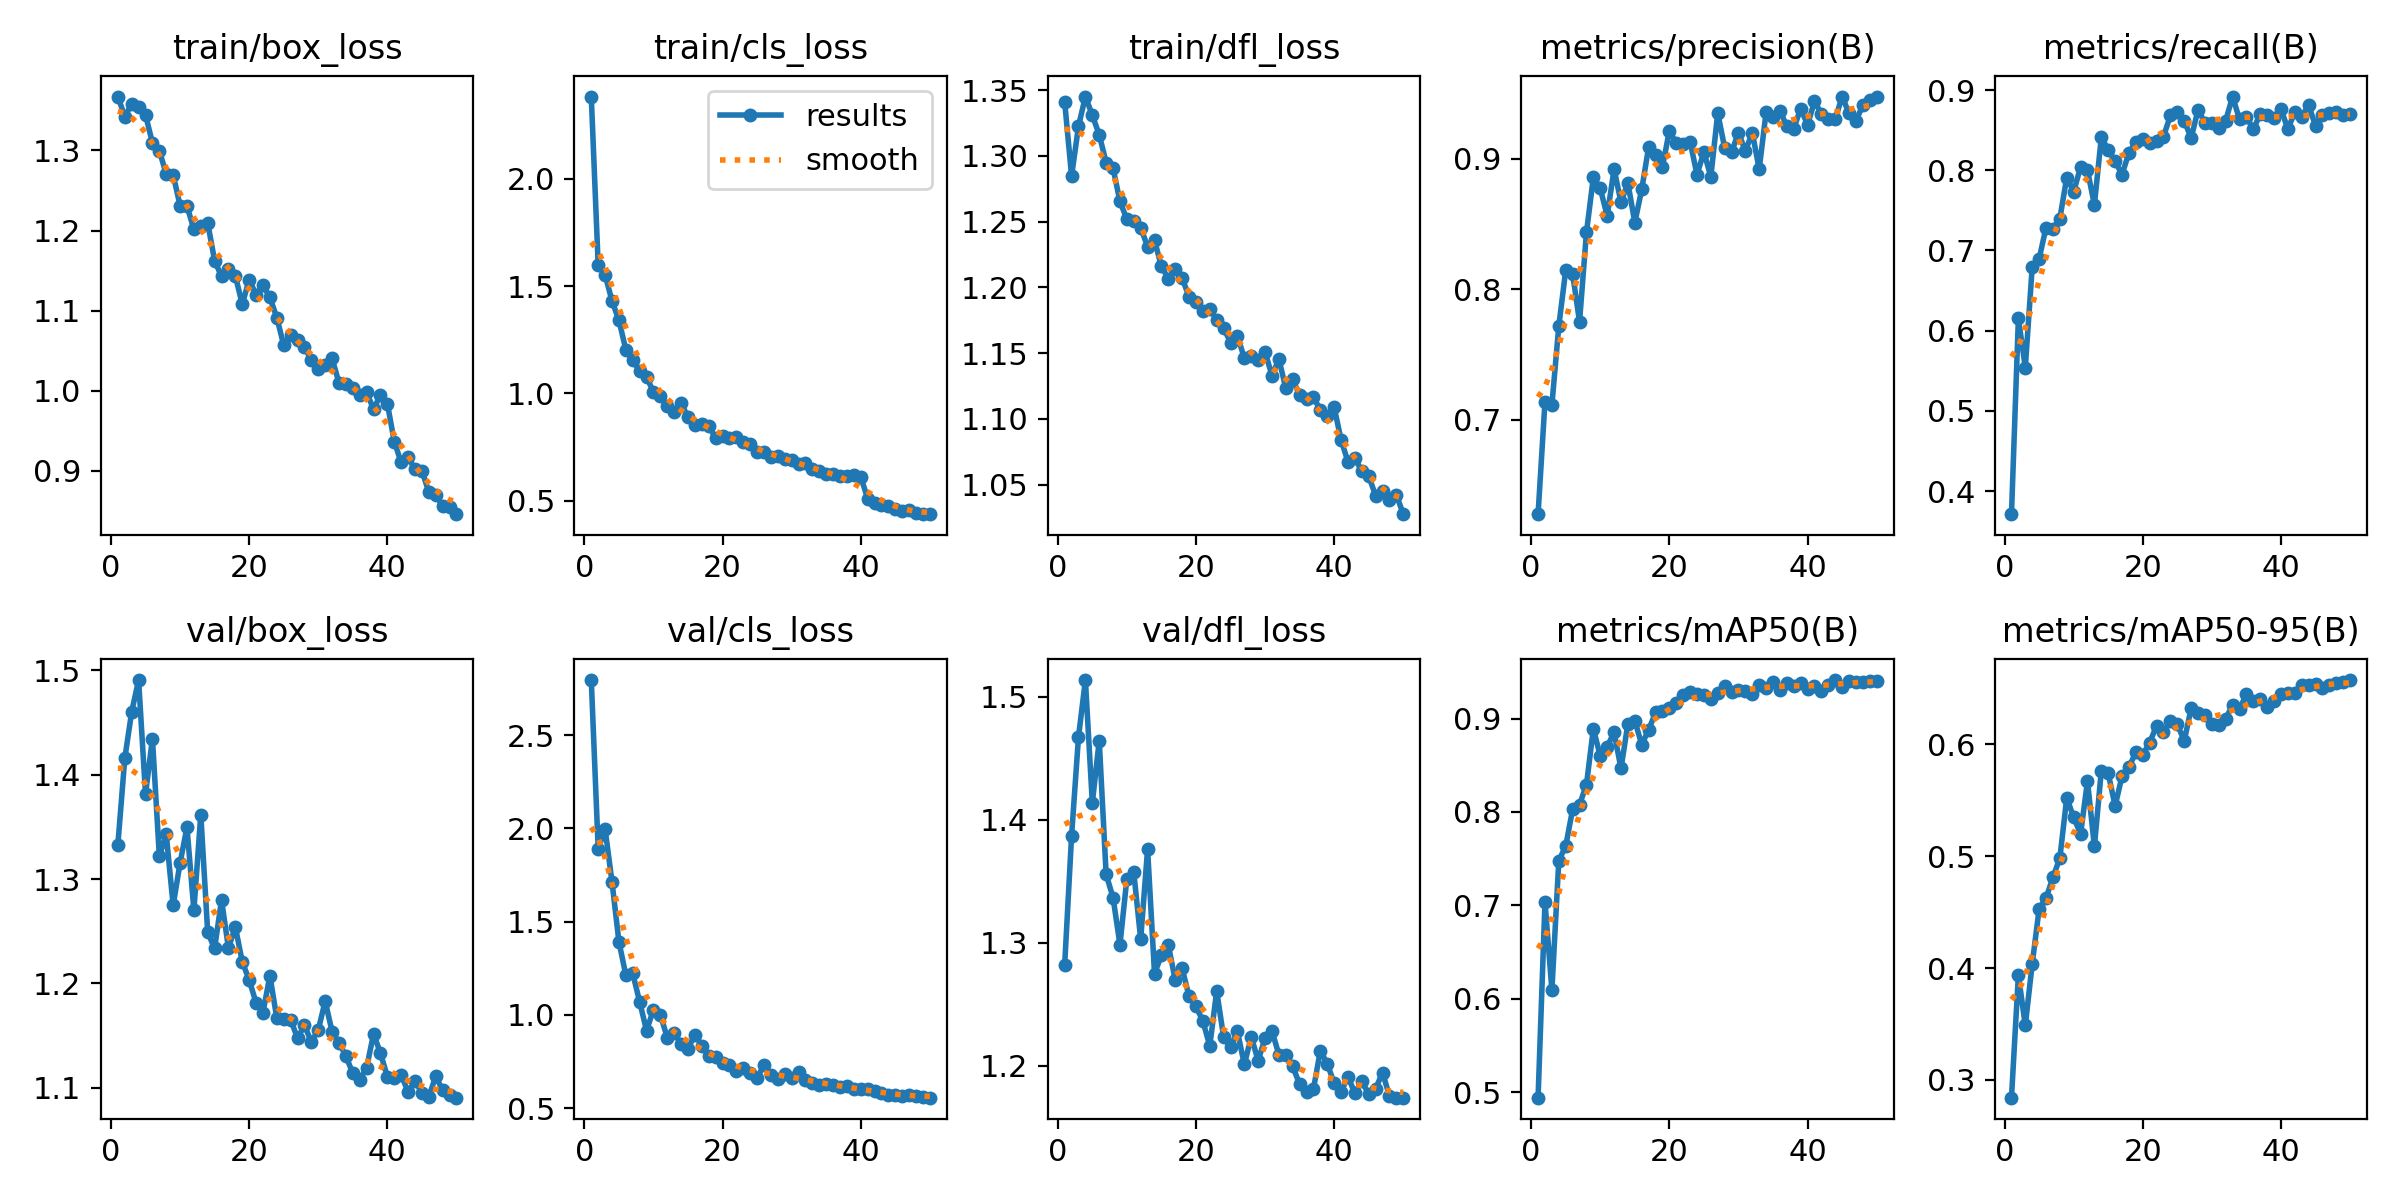

In [16]:
from IPython.display import Image, display

display(Image(filename='/content/runs/helmet_detection/results.png', width=900))

## 5️. Generar evidencias: imágenes con bounding boxes

Corremos el modelo sobre imágenes del set de prueba (`test`) y guardamos los resultados con las cajas dibujadas — estas son las imágenes que vas a subir a la carpeta `evidencias/` de tu repositorio.

In [17]:
import os

# Carpeta de imágenes de prueba dentro del dataset descargado
test_images_path = '/content/dataset/test/images'

# Corremos predicción y guardamos las imágenes con las cajas dibujadas
pred_results = best_model.predict(
    source=test_images_path,
    save=True,
    conf=0.4,        # confianza mínima para mostrar una detección
    project='/content/runs',
    name='evidencias'
)

print(f"\n✅ Imágenes con detecciones guardadas en: /content/runs/evidencias")


image 1/403 /content/dataset/test/images/-1-_jpg.rf.84d1cee2a985776904820bf1cf328095.jpg: 384x640 1 helmet, 1 no-helmet, 43.8ms
image 2/403 /content/dataset/test/images/-10-_-_-__yythk-1-_jpg.rf.771be81aa42eedd29199de7d20a76dfc.jpg: 352x640 1 no-helmet, 1 wrong-helmet, 39.4ms
image 3/403 /content/dataset/test/images/-T-_-_-_-YTN_jpg.rf.15ec896187d69d748af3cd7595a98246.jpg: 640x448 1 no-helmet, 38.2ms
image 4/403 /content/dataset/test/images/-_-1-_jpg.rf.21f7d42542e738844c9f6336aef3023b.jpg: 576x640 1 no-helmet, 37.7ms
image 5/403 /content/dataset/test/images/-_-_-1-_jpg.rf.242fff7fcd289cf54baba98043541377.jpg: 384x640 2 no-helmets, 6.6ms
image 6/403 /content/dataset/test/images/-_-_-27-_jpg.rf.d3686c24437f88e93d67f3ea8ee0453d.jpg: 448x640 1 no-helmet, 40.9ms
image 7/403 /content/dataset/test/images/-_-_-_-9-_jpg.rf.0c828495e196a61f6f86897504442bd4.jpg: 640x448 (no detections), 7.1ms
image 8/403 /content/dataset/test/images/-_-_-_-_-JTBC-_jpg.rf.30f3028577bf39922f7bdefce41af421.jpg: 64

### Vista previa de algunas evidencias

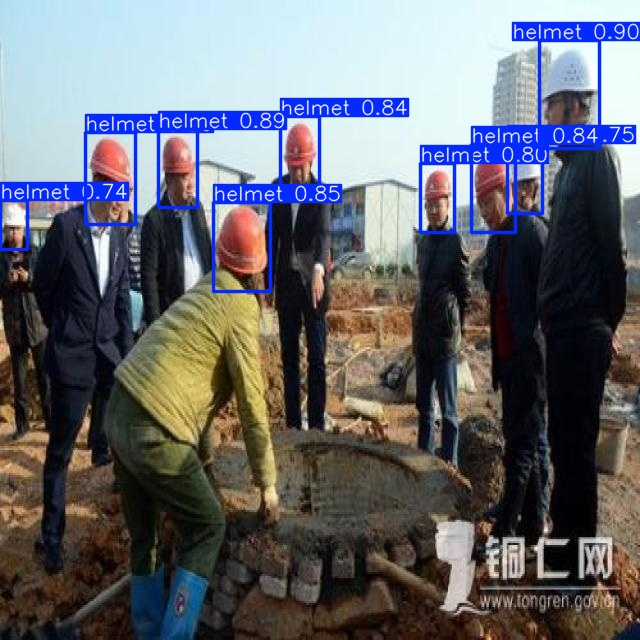

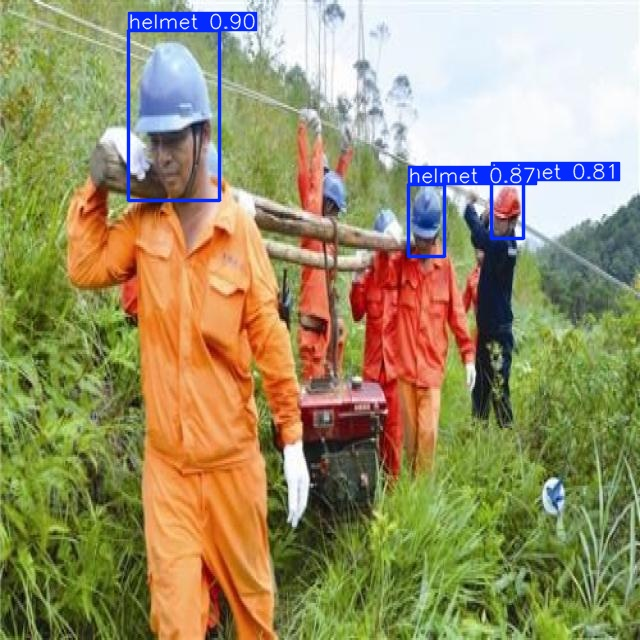

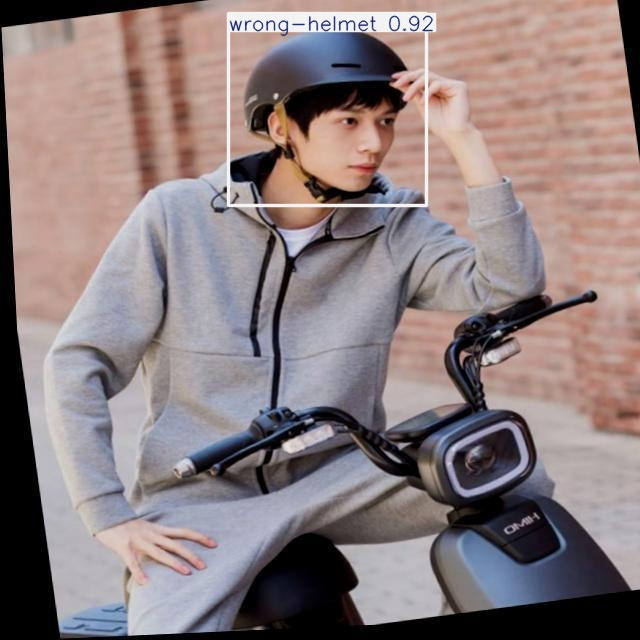

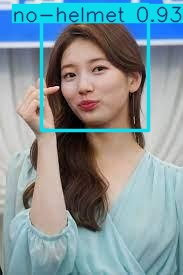

In [18]:
import glob
from IPython.display import Image, display

evidencias = glob.glob('/content/runs/evidencias/*.jpg')[:4]

for img_path in evidencias:
    display(Image(filename=img_path, width=500))

## 6️. Descargar resultados (pesos del modelo + evidencias)

Comprimimos las evidencias y el modelo entrenado para descargarlos y subirlos a tu repositorio de GitHub.

In [19]:
import shutil
from google.colab import files

# Comprimimos la carpeta de evidencias
shutil.make_archive('/content/evidencias', 'zip', '/content/runs/evidencias')

# Comprimimos las gráficas de resultados del entrenamiento
shutil.make_archive('/content/resultados_entrenamiento', 'zip', '/content/runs/helmet_detection')

print("✅ Archivos comprimidos listos para descargar:")
print("   - evidencias.zip → imágenes con bounding boxes")
print("   - resultados_entrenamiento.zip → gráficas, métricas y pesos del modelo (best.pt)")

# Descarga automática (puede pedir permiso del navegador)
files.download('/content/evidencias.zip')
files.download('/content/resultados_entrenamiento.zip')

✅ Archivos comprimidos listos para descargar:
   - evidencias.zip → imágenes con bounding boxes
   - resultados_entrenamiento.zip → gráficas, métricas y pesos del modelo (best.pt)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>